In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 29 — Differentiable simulation, graph physics and attention constraints

Differentiable manufactured oscillator simulation; a graph built from an observed digit image; explicit attention and force counterexamples.

This is an executed reference, not a learner assessment. Read the lesson and predict the results before running. All code is inspectable in `src/shape_lab/physics`. No model or dataset downloads occur.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
STAGE=29
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT.parent!=ROOT:ROOT=ROOT.parent
if not (ROOT/'pyproject.toml').exists():raise RuntimeError('Open this notebook within the extracted project.')
sys.path.insert(0,str(ROOT/'src'))
from shape_lab.physics import classical as c, constraints as con, gradients as grad, operators as op
hahn=pd.read_csv(ROOT/'data/physics/hahn1_excerpt.csv')
hahn_manifest=json.loads((ROOT/'data/physics/manifest.json').read_text())
OUT=ROOT/'physics/reports'/f'{STAGE:02d}'
OUT.mkdir(parents=True,exist_ok=True)
def save_report(result):
    result={'stage':STAGE,'role':'executed teaching experiment; not learner assessment',**result}
    result['source_review_date']='2026-09-20'
    (OUT/'results.json').write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    print(json.dumps(result,indent=2))
def finish_figure(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=140,bbox_inches='tight');plt.show();plt.close()
print('Course:', ROOT.name, '| stage:', STAGE)


Course: course | stage: 29


## Differentiate a numerical solution
Compare direct differentiation of RK4 with the exact decay sensitivity, then fit a damping coefficient on a manufactured oscillator trajectory.

Generating damping: 0.15 fitted: 0.1499932632346855


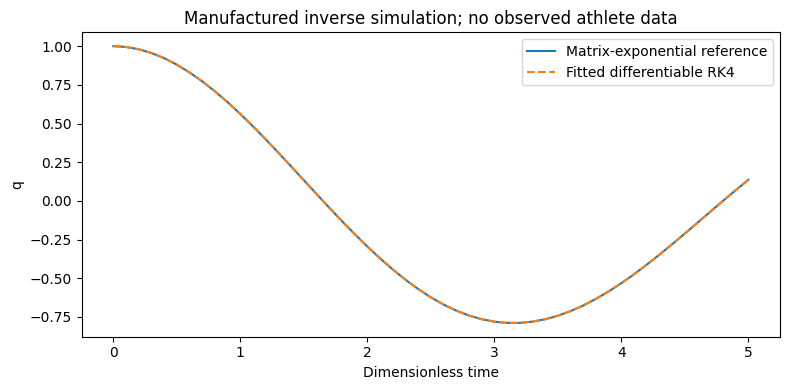

In [3]:
import torch
from scipy.linalg import expm
from shape_lab.physics.neural import rk4_torch,setup
setup(7)
rate=torch.tensor(.3,dtype=torch.float64,requires_grad=True)
z=rk4_torch(lambda t,x:-rate*x,torch.ones(1,dtype=torch.float64),.05,20)
sensitivity=float(torch.autograd.grad(z[-1].sum(),rate)[0].detach())
assert abs(sensitivity+np.exp(-.3))<1e-7
true_gamma=.15;times=np.arange(51)*.1
A=np.array([[0.,1.],[-1.,-true_gamma]])
truth=np.stack([expm(A*t)@np.array([1.,0.]) for t in times])
target=torch.from_numpy(truth);log_gamma=torch.tensor(np.log(.5),dtype=torch.float64,requires_grad=True)
optimizer=torch.optim.Adam([log_gamma],lr=.06)
for i in range(160):
    gamma=log_gamma.exp()
    pred=rk4_torch(lambda t,z:torch.stack([z[1],-z[0]-gamma*z[1]]),torch.tensor([1.,0.],dtype=torch.float64),.1,50)
    loss=(pred-target).square().mean();optimizer.zero_grad();loss.backward();optimizer.step()
estimate=float(log_gamma.exp().detach());print('Generating damping:',true_gamma,'fitted:',estimate)
assert np.isfinite(estimate)
plt.figure(figsize=(8,4));plt.plot(times,truth[:,0],label='Matrix-exponential reference');plt.plot(times,pred[:,0].detach().numpy(),'--',label='Fitted differentiable RK4');plt.legend();plt.xlabel('Dimensionless time');plt.ylabel('q');plt.title('Manufactured inverse simulation; no observed athlete data');finish_figure('inverse_simulation')

## Pairwise balance on a real image graph
Neighbors exchange equal and opposite amounts. The pixel observations are real; this diffusion update is constructed.

In [4]:
from shape_lab.data import digit_example
image,sample_id=digit_example(3);values=image.astype(float).reshape(-1,1)
edges=[]
for r in range(8):
    for col in range(8):
        i=8*r+col
        if col<7:edges.append((i,i+1,1.))
        if r<7:edges.append((i,i+8,1.))
F=op.pair_forces(values,edges);updated=values+.1*F
net=float(F.sum());sum_error=float(abs(updated.sum()-values.sum()))
assert abs(net)<1e-12 and sum_error<1e-12
attention=np.array([[1.,0.],[1.,0.]])
input_mass=np.array([1.,0.]);output_mass=attention@input_mass
assert output_mass.sum()==2
save_report({'data_kind':'manufactured differentiable dynamics plus constructed exchanges on real digit intensities','rk4_parameter_sensitivity':sensitivity,'exact_decay_sensitivity':float(-np.exp(-.3)),'manufactured_true_damping':true_gamma,'fitted_damping':estimate,'training_trajectory_mse':float(loss.detach()),'measured_dynamics_used':False,'digit_sample_id':sample_id,'graph_edges':len(edges),'graph_total_update':net,'graph_intensity_sum_error':sum_error,'attention_input_sum':float(input_mass.sum()),'attention_output_sum':float(output_mass.sum()),'PINNsFormer_benchmark_trained':False,'unsupported':'No trained graph simulator, contact sensitivity or GPU throughput claim.'})

{
  "stage": 29,
  "role": "executed teaching experiment; not learner assessment",
  "data_kind": "manufactured differentiable dynamics plus constructed exchanges on real digit intensities",
  "rk4_parameter_sensitivity": -0.7408182191903769,
  "exact_decay_sensitivity": -0.7408182206817179,
  "manufactured_true_damping": 0.15,
  "fitted_damping": 0.1499932632346855,
  "training_trajectory_mse": 1.0547861051280454e-10,
  "measured_dynamics_used": false,
  "digit_sample_id": 13,
  "graph_edges": 112,
  "graph_total_update": 0.0,
  "graph_intensity_sum_error": 0.0,
  "attention_input_sum": 1.0,
  "attention_output_sum": 2.0,
  "PINNsFormer_benchmark_trained": false,
  "unsupported": "No trained graph simulator, contact sensitivity or GPU throughput claim.",
  "source_review_date": "2026-09-20"
}


## Independent explanation

Write the data origin, one supported conclusion and one unsupported conclusion. Change one parameter while preserving the comparison horizon or unit. Save your answer separately; successful reference execution is not proof that you understand the result.